In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import math
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import seaborn as sns
import sys
import os

In [2]:
sys.path.append(os.path.abspath("../src"))
from utils.raw_data_query import get_data_query

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)

# Loading data tables and joining them

In [4]:
USER = "chembl"
PASSWORD = "chembl"
HOST = "localhost"
PORT = "5432"
DB = "chembl"

In [5]:
engine = create_engine(f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}")
engine.connect()
query = get_data_query()

In [6]:
df = pd.read_sql(query, engine)
df.head()

,activity_id,assay_id,molregno,ic50,standard_units,smiles,assay_type,confidence_score,target_id,chembl_id,target_type,organism,molregno,mw_freebase,alogp,hba,hbd,psa,rtb,ro3_pass,num_ro5_violations,full_mwt,aromatic_rings,heavy_atoms,qed_weighted,full_molformula,np_likeness_score
0,3110091,612411,599614,3.0,ug.mL-1,CC(C)Cn1c2ccccc2c2ccnc(C3=C[C@@]4(O)CC/C=C\CCC...,F,1,50436,CHEMBL365,ORGANISM,Cryptococcus neoformans,599614,604.88,7.99,5.0,1.0,44.53,3.0,N,2.0,604.88,3.0,45.0,0.31,C40H52N4O,1.66
1,3116477,610721,596332,36000.0,nM,COc1ccc(C(CC(=O)N[C@@H](CC(C)C)B(O)O)NC(=O)c2c...,F,1,81024,CHEMBL396,CELL-LINE,Homo sapiens,596332,412.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,412.30,NaN,NaN,NaN,C22H29BN2O5,NaN
2,3116485,610723,596332,1080.0,nM,COc1ccc(C(CC(=O)N[C@@H](CC(C)C)B(O)O)NC(=O)c2c...,F,1,80526,CHEMBL612544,CELL-LINE,Homo sapiens,596332,412.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,412.30,NaN,NaN,NaN,C22H29BN2O5,NaN
3,3240745,624976,623603,100.0,nM,O=C(Nc1cccc(-c2nc3sccn3c2-c2ccnc(Nc3ccc4c(c3)C...,B,9,234,CHEMBL1957,SINGLE PROTEIN,Homo sapiens,623603,579.64,6.44,8.0,3.0,96.24,6.0,N,2.0,579.64,6.0,42.0,0.21,C31H23F2N7OS,-1.75
4,3242020,624459,620788,0.7,nM,CN1CCN(c2ccc(NC(=O)Nc3ccc(-c4nc(C5=CCOCC5)nc(N...,B,8,11400,CHEMBL2842,SINGLE PROTEIN,Homo sapiens,620788,582.71,4.11,9.0,2.0,107.98,6.0,N,1.0,582.71,3.0,43.0,0.44,C32H38N8O3,-0.82


In [7]:
len(df)

2357054

# Missing values and data types

In [8]:
df.isna().sum()

activity_id               0
assay_id                  0
molregno                  0
ic50                      0
standard_units            0
smiles                    0
assay_type                0
confidence_score          0
target_id                 0
chembl_id                 0
molregno                  0
mw_freebase               0
alogp                 56666
hba                   56666
hbd                   56666
psa                   56666
rtb                   56666
ro3_pass              56666
num_ro5_violations    56666
full_mwt                  0
aromatic_rings        56666
heavy_atoms           56666
qed_weighted          56666
full_molformula           0
np_likeness_score     56666
dtype: int64

In [9]:
df.dtypes

activity_id             int64
assay_id                int64
molregno                int64
ic50                  float64
standard_units            str
smiles                    str
assay_type                str
confidence_score        int64
target_id               int64
chembl_id                 str
molregno                int64
mw_freebase           float64
alogp                 float64
hba                   float64
hbd                   float64
psa                   float64
rtb                   float64
ro3_pass                  str
num_ro5_violations    float64
full_mwt              float64
aromatic_rings        float64
heavy_atoms           float64
qed_weighted          float64
full_molformula           str
np_likeness_score     float64
dtype: object

# IC50


## Available units

In [10]:
df["standard_units"].value_counts()

standard_units
nM                 2300885
ug.mL-1              54256
ug                     221
molar ratio            202
mg kg-1                175
ppm                    156
10^2 uM                113
%                      112
equiv                   84
10^-7mol/L              74
% conc                  62
10^-8mol/L              60
10^-9mol/L              55
uM well-1               42
mMequiv                 38
p.p.m.                  38
g/ha                    38
10^-5 uM                27
uL                      26
10^-4microM             24
milliequivalent         22
/uM                     21
ug/g                    20
10'-5g/L                18
10^3nM                  17
pmol/L                  16
M ml-1                  15
kJ m**-2                14
10^-6 mol/L             10
umol/Kg                 10
10^-2microM              9
mol                      9
10^-10mol/L              9
mmol/Kg                  9
min                      9
uM tube-1                9
ug well-1    

## Calculation of pIC50

In [7]:
df["pic50"] = -np.log10(df["ic50"] * 1e-9)

## Distribution of pIC50 values

In [12]:
df = df[df["standard_units"] == "nM"].copy()

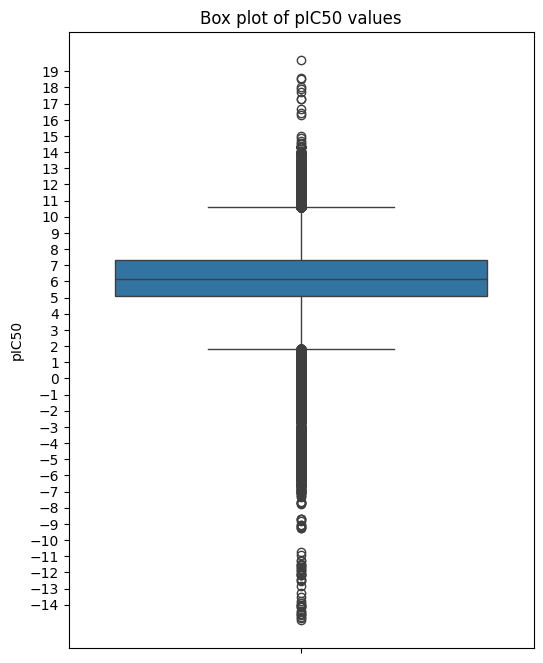

In [13]:
plt.figure(figsize=(6, 8))

sns.boxplot(y=df["pic50"])
plt.title("Box plot of pIC50 values")
plt.ylabel("pIC50")

y_min = int(df["pic50"].min())
y_max = int(df["pic50"].max())
plt.yticks(np.arange(y_min, y_max + 1, 1))

plt.show()

# Target

In [7]:
df['organism'].value_counts()

organism
Homo sapiens                                                                                                                                       1641483
Rattus norvegicus                                                                                                                                    85042
Mus musculus                                                                                                                                         67323
Plasmodium falciparum                                                                                                                                52463
Human immunodeficiency virus 1                                                                                                                       28549
Trypanosoma cruzi                                                                                                                                    13028
Bos taurus                                                   

In [8]:
df['target_type'].value_counts()

target_type
SINGLE PROTEIN                  1265716
CELL-LINE                        543010
UNCHECKED                        193692
ORGANISM                         155237
PROTEIN COMPLEX                   62643
NON-MOLECULAR                     62524
PROTEIN FAMILY                    31188
PROTEIN-PROTEIN INTERACTION        9439
PROTEIN COMPLEX GROUP              9122
ADMET                              8397
NO TARGET                          4959
TISSUE                             3957
UNKNOWN                            3362
CHIMERIC PROTEIN                   1357
NUCLEIC-ACID                        983
SELECTIVITY GROUP                   468
SUBCELLULAR                         459
PROTEIN NUCLEIC-ACID COMPLEX        224
MACROMOLECULE                       211
SMALL MOLECULE                      103
3D CELL CULTURE                       3
Name: count, dtype: int64

# Assays

## Type

assay_type
B    1394482
F     834354
A      59470
T      11234
P       1236
U        109
Name: count, dtype: int64


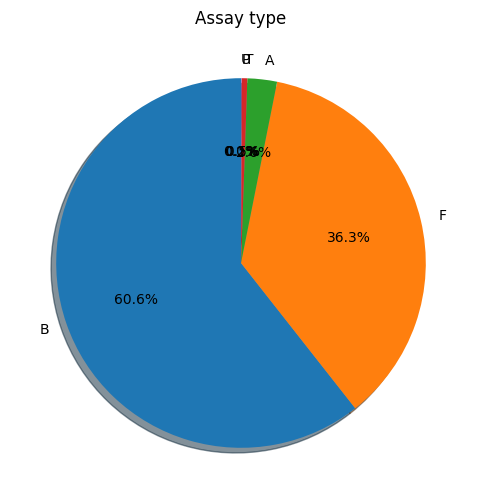

In [14]:
counts = df["assay_type"].value_counts()
print(counts)

plt.figure(figsize=(6,6))
counts.plot.pie(autopct='%1.1f%%', startangle=90, shadow=True)
plt.title("Assay type")
plt.ylabel("")
plt.show()

## Confidence

In [15]:
percentages = df["confidence_score"].value_counts(normalize=True) * 100
percentages

confidence_score
9    39.495368
1    31.270055
8    15.324842
0     8.783359
7     1.852896
5     1.101098
4     1.028430
6     0.955024
3     0.169804
2     0.019123
Name: proportion, dtype: float64

# Chemical properties

In [8]:
properites = [
    "pic50", 
    "mw_freebase", 
    "alogp", 
    "hba", 
    "hbd", 
    "psa", 
    "rtb", 
    "full_mwt", 
    "qed_weighted", 
    "np_likeness_score", 
    "aromatic_rings"
]

In [17]:
df_properites = df[properites].copy()

In [18]:
df_properites.describe()

,pic50,mw_freebase,alogp,hba,hbd,psa,rtb,full_mwt,qed_weighted,np_likeness_score,aromatic_rings
count,2.300885e+06,2.300885e+06,2.246502e+06,2.246502e+06,2.246502e+06,2.246502e+06,2.246502e+06,2.300885e+06,2.246502e+06,2.246502e+06,2.246502e+06
mean,6.235615e+00,4.615605e+02,3.864246e+00,5.856307e+00,1.843403e+00,9.061844e+01,5.994954e+00,4.642555e+02,4.845303e-01,-7.194495e-01,2.860880e+00
std,1.487909e+00,2.343257e+02,1.841074e+00,2.474801e+00,1.492433e+00,4.161269e+01,3.609484e+00,2.352240e+02,2.066730e-01,1.025176e+00,1.261675e+00
min,-1.495000e+01,6.940000e+00,-1.175000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.940000e+00,1.000000e-02,-4.060000e+00,0.000000e+00
25%,5.104025e+00,3.583900e+02,2.800000e+00,4.000000e+00,1.000000e+00,6.411000e+01,4.000000e+00,3.604200e+02,3.300000e-01,-1.390000e+00,2.000000e+00
50%,6.132533e+00,4.323100e+02,3.860000e+00,6.000000e+00,2.000000e+00,8.615000e+01,5.000000e+00,4.344100e+02,4.800000e-01,-9.400000e-01,3.000000e+00
75%,7.301030e+00,5.113900e+02,4.940000e+00,7.000000e+00,3.000000e+00,1.097500e+02,8.000000e+00,5.136400e+02,6.500000e-01,-3.200000e-01,4.000000e+00
max,1.969101e+01,9.517930e+03,1.844000e+01,3.200000e+01,2.500000e+01,5.683900e+02,5.900000e+01,9.517930e+03,9.500000e-01,4.130000e+00,2.800000e+01


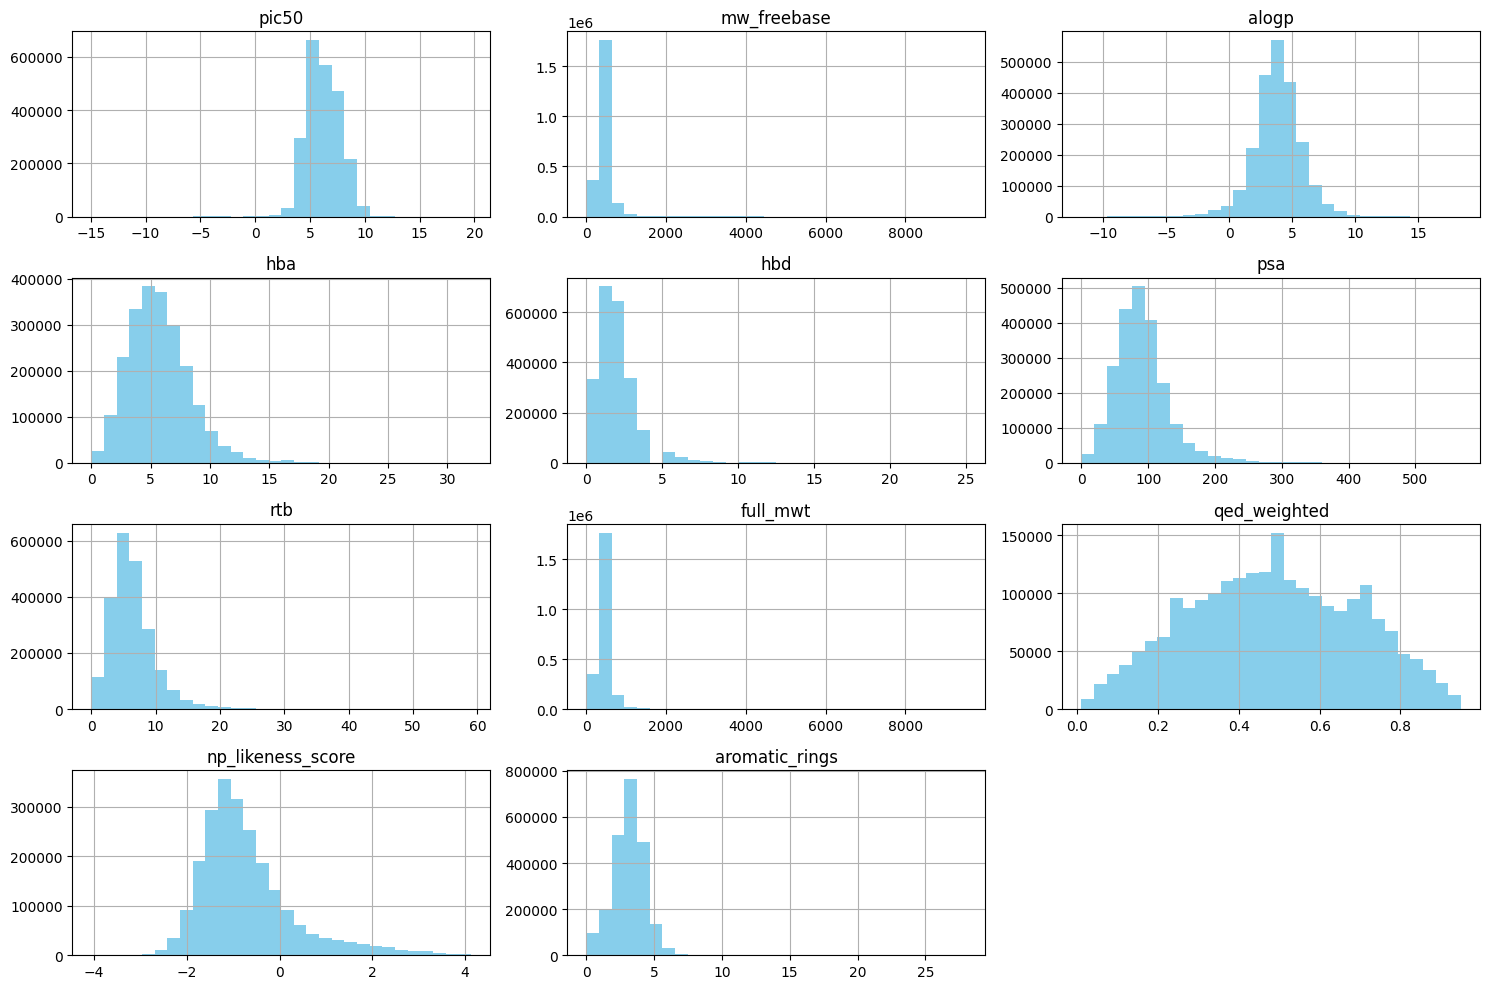

In [19]:
df_properites = df_properites.apply(pd.to_numeric, errors='coerce') 

df_properites.hist(bins=30, figsize=(15,10), color='skyblue')
plt.tight_layout()
plt.show()

# Correlations

In [9]:
df_quality = df[
    (df['assay_type'] == 'B') &
    (df['confidence_score'] > 6) &
    (df['pic50'] > 2) &
    (df['pic50'] < 13) &
    (df['target_type'] == 'SINGLE PROTEIN') &
    (df['organism'] == 'Homo sapiens')
].copy()

In [10]:
len(df_quality)

968588

In [11]:
corr_matrix = df_quality[properites].corr()

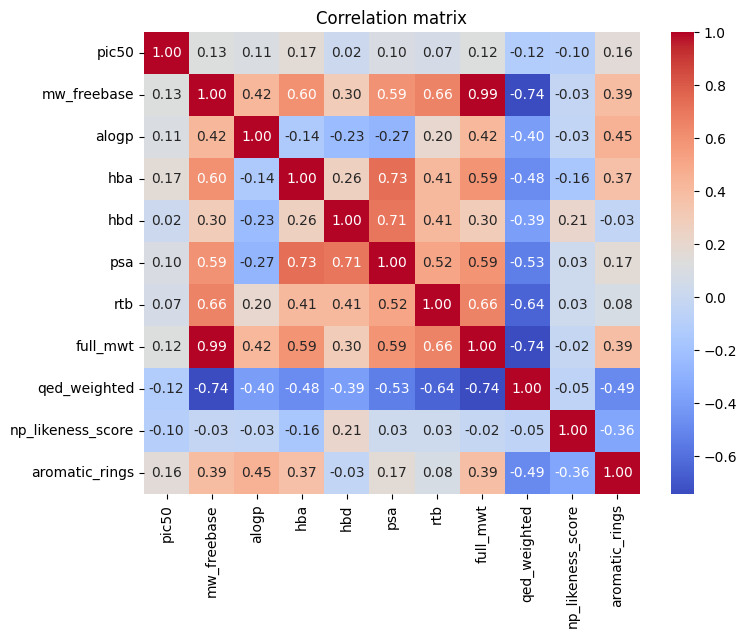

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()